## 1. Impressions Data Preparation

- Small MIND training dataset used for EDA (large MIND training dataset exceeds Colab RAM)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import gc

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Read and explore behaviors dataset
behaviors = pd.read_csv(
    "/content/drive/MyDrive/Y4S1/BT4222/MINDsmall_train/behaviors.tsv",
    sep="\t",
    header=None,
    names=[
        "impression_id",
        "user_id",
        "time",
        "history",
        "impressions"
    ]
)
behaviors["time"] = pd.to_datetime(
    behaviors["time"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

print("Rows:", len(behaviors))
print("Users:", behaviors["user_id"].nunique())
print("Time range:", behaviors["time"].min(), "to", behaviors["time"].max())
behaviors.head()

Rows: 156965
Users: 50000
Time range: 2019-11-09 00:00:19 to 2019-11-14 23:59:13


,impression_id,user_id,time,history,impressions
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,2019-11-11 05:28:05,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,2019-11-12 16:11:21,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [4]:
# Prepare impressions dataset
impressions = (
    behaviors[
        [
            "impression_id",
            "user_id",
            "time",
            "impressions"
        ]
    ]
    .assign(
        impression_item=lambda df: (
            df["impressions"]
            .astype(str)
            .str.split()
        ) # Split impressions into lists of "new_id-clicked" strings
    )
    .explode("impression_item") # Each news id in a separate row
    .drop(columns="impressions")
)

impressions["news_id"] = (
    impressions["impression_item"]
    .str.rsplit("-", n=1)
    .str[0]
)

impressions["clicked"] = (
    impressions["impression_item"]
    .str.rsplit("-", n=1)
    .str[1]
    .astype("int8")
)

impressions["position"] = (
    impressions
    .groupby("impression_id")
    .cumcount()
    .add(1)
)

# Display results
print("Article exposure records:", len(impressions))
print("Clicked articles:", impressions["clicked"].sum())
print("Unclicked exposed articles:", (impressions["clicked"] == 0).sum())
print("Article-level CTR:", impressions["clicked"].mean())
impressions.head()

Article exposure records: 5843444
Clicked articles: 236344
Unclicked exposed articles: 5607100
Article-level CTR: 0.040446010948338


,impression_id,user_id,time,impression_item,news_id,clicked,position
0,1,U13740,2019-11-11 09:05:58,N55689-1,N55689,1,1
0,1,U13740,2019-11-11 09:05:58,N35729-0,N35729,0,2
1,2,U91836,2019-11-12 18:11:30,N20678-0,N20678,0,1
1,2,U91836,2019-11-12 18:11:30,N39317-0,N39317,0,2
1,2,U91836,2019-11-12 18:11:30,N58114-0,N58114,0,3


## 2. Impression Slate & Position Distribution

### 2.1 Slate Length Distribution

In [5]:
# Get slate-level summary statistics
slate_summary = (
    impressions
    .groupby("impression_id")
    .agg(
        slate_length=("news_id", "size"),
        clicks=("clicked", "sum")
    )
    .reset_index()
)
slate_summary["has_click"] = (
    slate_summary["clicks"] > 0
).astype(int)
slate_summary.describe()

,impression_id,slate_length,clicks,has_click
count,156965.000000,156965.000000,156965.000000,156965.0
mean,78483.000000,37.227688,1.505711,1.0
std,45312.036839,38.594148,1.153102,0.0
min,1.000000,2.000000,1.000000,1.0
25%,39242.000000,10.000000,1.000000,1.0
50%,78483.000000,24.000000,1.000000,1.0
75%,117724.000000,51.000000,2.000000,1.0
max,156965.000000,299.000000,35.000000,1.0


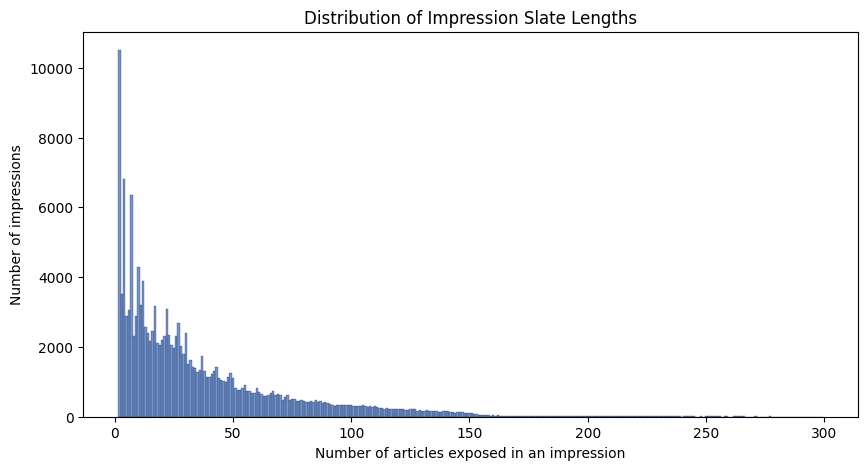

In [6]:
# Plot slate length distribution
plt.figure(figsize=(10, 5))
sns.histplot(
    data=slate_summary,
    x="slate_length",
    discrete=True,
    color="#4472C4"
)

plt.title("Distribution of Impression Slate Lengths")
plt.xlabel("Number of articles exposed in an impression")
plt.ylabel("Number of impressions")
plt.show()

**Observations:**

1. Slate length is skewed towards the right, so the number of articles exposed in an impression lies around 0-50

### 2.2 CTR across slate lengths

In [7]:
slate_length_summary = (
    slate_summary
    .groupby("slate_length")
    .agg(
        impressions=("impression_id", "size"),
        total_clicks=("clicks", "sum"),
        impressions_with_click=("has_click", "sum")
    )
    .reset_index()
)

slate_length_summary["article_level_ctr"] = (
    slate_length_summary["total_clicks"]
    / (
        slate_length_summary["slate_length"]
        * slate_length_summary["impressions"]
    )
)

slate_length_summary["impression_click_rate"] = (
    slate_length_summary["impressions_with_click"]
    / slate_length_summary["impressions"]
)

slate_length_summary

,slate_length,impressions,total_clicks,impressions_with_click,article_level_ctr,impression_click_rate
0,2,10509,10509,10509,0.500000,1.0
1,3,3504,3544,3504,0.337139,1.0
2,4,6809,7036,6809,0.258335,1.0
3,5,2889,3001,2889,0.207754,1.0
4,6,3053,3270,3053,0.178513,1.0
...,...,...,...,...,...,...
291,293,1,3,1,0.010239,1.0
292,294,4,8,4,0.006803,1.0
293,295,2,3,2,0.005085,1.0
294,297,1,1,1,0.003367,1.0


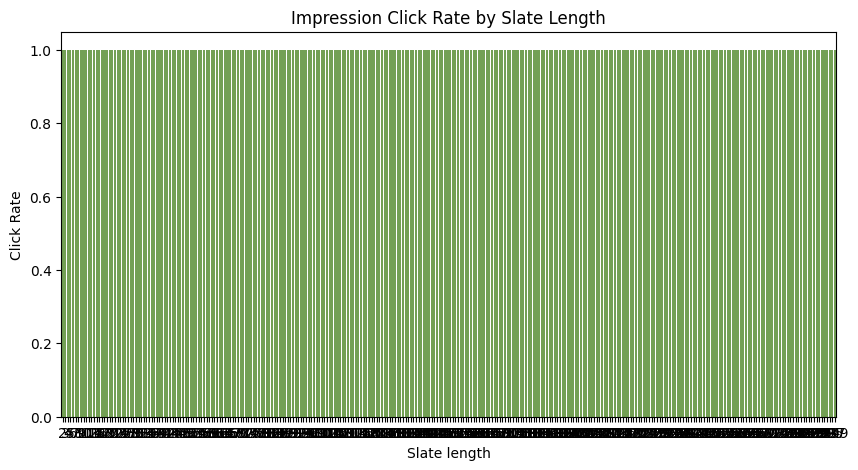

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=slate_length_summary,
    x="slate_length",
    y="impression_click_rate",
    color="#70AD47"
)

plt.title("Impression Click Rate by Slate Length")
plt.xlabel("Slate length")
plt.ylabel("Click Rate")
plt.show()

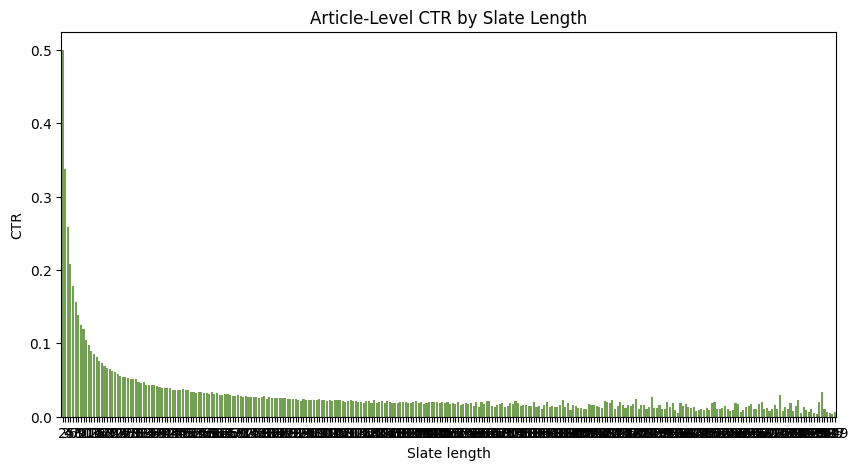

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=slate_length_summary,
    x="slate_length",
    y="article_level_ctr",
    color="#70AD47"
)

plt.title("Article-Level CTR by Slate Length")
plt.xlabel("Slate length")
plt.ylabel("CTR")
plt.show()

**Observations**

1. `impression_click_rate` is 1.0 for all rows, meaning that every impression has at least one article clicked.
2. The CTR on article-level is right-skewed, so for impressions with less slate length, the click-through rate tend to be higher.

### 2.3 CTR across positions

In [10]:
position_summary = (
    impressions
    .groupby("position")
    .agg(
        exposures=("news_id", "size"),
        clicks=("clicked", "sum"),
        ctr=("clicked", "mean")
    )
    .reset_index()
)

position_summary.head(15)

,position,exposures,clicks,ctr
0,1,156965,16991,0.108247
1,2,156965,16917,0.107776
2,3,146456,11850,0.080912
3,4,142952,10655,0.074536
4,5,136143,8958,0.065798
5,6,133254,8186,0.061432
6,7,130201,7749,0.059516
7,8,123836,6741,0.054435
8,9,121522,6321,0.052015
9,10,118644,5977,0.050378


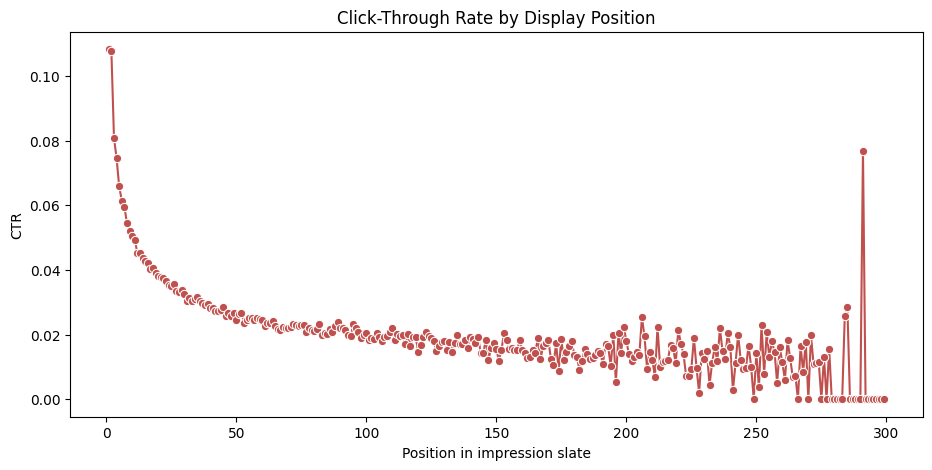

In [11]:
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=position_summary,
    x="position",
    y="ctr",
    marker="o",
    color="#C0504D"
)

plt.title("Click-Through Rate by Display Position")
plt.xlabel("Position in impression slate")
plt.ylabel("CTR")
plt.show()

**Observations:**

1. CTR generally drops as the position increases, except towards the end where it spiked at around position 275 (likely outlier?).

## 3. Interaction Hierachy & Funnel

### 3.1 Article-level

- Article exposure → Article click

In [13]:
funnel = pd.DataFrame({
    "stage": [
        "Article exposures",
        "Article clicks"
    ],
    "count": [
        len(impressions),
        impressions["clicked"].sum()
    ]
})

funnel["conversion_from_previous_stage"] = [
    np.nan,
    funnel.loc[1, "count"] / funnel.loc[0, "count"]
]

funnel

,stage,count,conversion_from_previous_stage
0,Article exposures,5843444,NaN
1,Article clicks,236344,0.040446


**Observations**:

1. Low percentage (~4%) of articles exposed gets clicked

### 3.2 Impression-level

In [20]:
impression_click_behavior = (
    slate_summary
    .assign(
        click_group=lambda df: np.select(
            [
                df["clicks"] == 0,
                df["clicks"] == 1,
                df["clicks"] > 1
            ],
            [
                "No clicks",
                "Exactly one click",
                "Multiple clicks"
            ],
            default="Unknown" 
        )
    )
    .groupby("click_group")
    .size()
    .reset_index(name="impressions")
)

impression_click_behavior["percentage"] = (
    impression_click_behavior["impressions"]
    / impression_click_behavior["impressions"].sum()
    * 100
)

impression_click_behavior

,click_group,impressions,percentage
0,Exactly one click,113888,72.556302
1,Multiple clicks,43077,27.443698


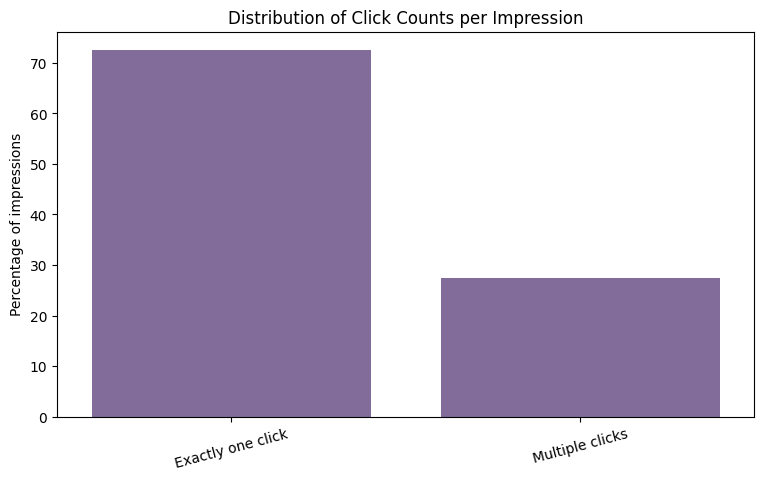

In [22]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=impression_click_behavior,
    x="click_group",
    y="percentage",
    color="#8064A2"
)

plt.title("Distribution of Click Counts per Impression")
plt.xlabel("")
plt.ylabel("Percentage of impressions")
plt.xticks(rotation=15)
plt.show()

**Observations**:

1. All impressions have at least one click
2. Most impressions (~72%) get exactly one click, ie only 1 article gets clicked in the pool of recommendations

## 4. Feedback Semantics

| State                                               | Meaning                             |
| --------------------------------------------------- | ----------------------------------- |
| `clicked = 1` in `impressions`                      | Article was exposed and clicked     |
| `clicked = 0` in `impressions`                      | Article was exposed but not clicked |
| Missing in `impressions` but present in `news.tsv`  | Article was not exposed             |

In [25]:
feedback = pd.DataFrame({
    "feedback_type": [
        "Exposed and clicked",
        "Exposed but not clicked"
    ],
    "count": [
        impressions["clicked"].sum(),
        (impressions["clicked"] == 0).sum()
    ]
})

feedback["percentage_of_exposures"] = (
    feedback["count"]
    / feedback["count"].sum()
    * 100
)

feedback

,feedback_type,count,percentage_of_exposures
0,Exposed and clicked,236344,4.044601
1,Exposed but not clicked,5607100,95.955399


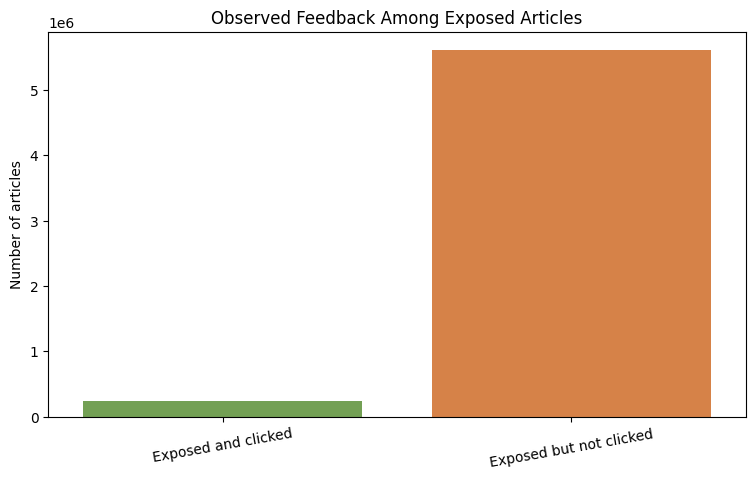

In [26]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=feedback,
    x="feedback_type",
    y="count",
    hue="feedback_type",
    palette=["#70AD47", "#ED7D31"],
    legend=False
)

plt.title("Observed Feedback Among Exposed Articles")
plt.xlabel("")
plt.ylabel("Number of articles")
plt.xticks(rotation=10)
plt.show()

**Observations**:

1. Very imbalanced dataset: More negative feedback (exposed but not clicked) compared to positive feedback (exposed and clicked)

## 5. Sparsity & Temporal Patterns

### 5.1 Historical click sequence length

In [29]:
def history_length(value):
    if pd.isna(value) or str(value).strip() == "":
        return 0
    return len(str(value).split())

behaviors["history_length"] = (
    behaviors["history"]
    .apply(history_length)
)

behaviors["history_length"].describe()

,history_length
count,156965.000000
mean,32.539987
std,40.267607
min,0.000000
25%,8.000000
50%,19.000000
75%,42.000000
max,558.000000


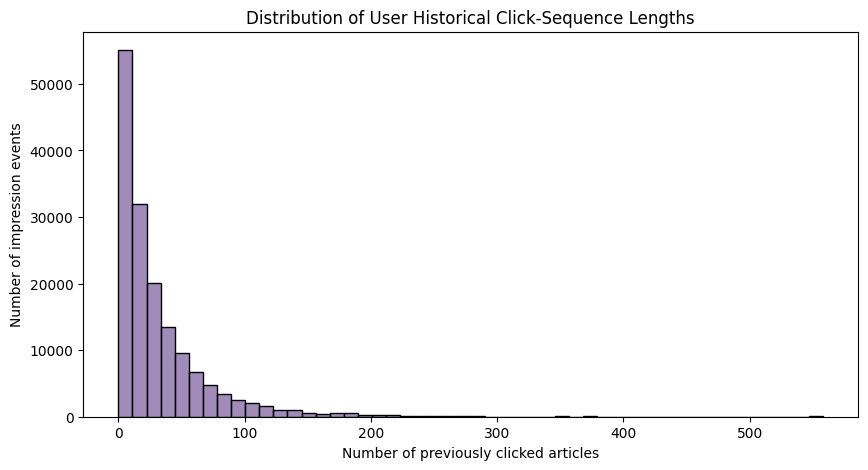

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=behaviors,
    x="history_length",
    bins=50,
    color="#8064A2"
)

plt.title("Distribution of User Historical Click-Sequence Lengths")
plt.xlabel("Number of previously clicked articles")
plt.ylabel("Number of impression events")
plt.show()

**Observations**:

1. The histogram is right-skewed, meaning that the historical click length before most impressions lies around 0-100.

## 6. Item Popularity

### 6.1 Item Popularity Distribution

- Item here refers to News

In [33]:
item_popularity = (
    impressions
    .groupby("news_id")
    .agg(
        exposures=("news_id", "size"),
        clicks=("clicked", "sum")
    )
    .reset_index()
)

item_popularity["ctr"] = (
    item_popularity["clicks"]
    / item_popularity["exposures"]
)

item_popularity = item_popularity.sort_values(
    "exposures",
    ascending=False
)

item_popularity.head(10) # Top 10 most exposed articles

,news_id,exposures,clicks,ctr
12704,N47061,23037,820,0.035595
14076,N51048,19242,1875,0.097443
5565,N26262,19106,1139,0.059615
14020,N50872,18702,279,0.014918
15685,N55689,18315,4316,0.235654
9880,N38779,18101,1490,0.082316
18074,N62360,16869,1594,0.094493
1375,N13907,16267,613,0.037684
13433,N49180,16022,1103,0.068843
10664,N41020,15551,1139,0.073243


### 6.2 Head and long-tail groups

In [34]:
item_popularity["exposure_rank"] = np.arange(
    1,
    len(item_popularity) + 1
)

item_popularity["article_percentile"] = (
    item_popularity["exposure_rank"]
    / len(item_popularity)
)

item_popularity["segment"] = np.select(
    [
        item_popularity["article_percentile"] <= 0.01,
        item_popularity["article_percentile"] <= 0.10
    ],
    [
        "Top 1% head",
        "Top 10% head"
    ],
    default="Long tail"
)

head_tail = (
    item_popularity
    .groupby("segment")
    .agg(
        unique_articles=("news_id", "nunique"),
        exposures=("exposures", "sum"),
        clicks=("clicks", "sum")
    )
    .reset_index()
)

head_tail["ctr"] = (
    head_tail["clicks"]
    / head_tail["exposures"]
)

head_tail

,segment,unique_articles,exposures,clicks,ctr
0,Long tail,18260,553507,19508,0.035244
1,Top 1% head,202,1894183,112164,0.059215
2,Top 10% head,1826,3395754,104672,0.030824


### 6.3 Time Gaps between User Actions

- User Actions here refers to each impression log/row

In [41]:
user_events = (
    behaviors
    .sort_values(["user_id", "time"])
    .copy()
)

user_events["previous_event_time"] = (
    user_events
    .groupby("user_id")["time"]
    .shift(1)
)

user_events["gap_minutes"] = (
    user_events["time"]
    - user_events["previous_event_time"]
).dt.total_seconds() / 60

time_gaps = user_events.dropna(
    subset=["gap_minutes"]
)

time_gaps["gap_minutes"].describe()

,gap_minutes
count,106965.000000
mean,1098.891267
std,1245.185059
min,0.000000
25%,128.850000
50%,768.950000
75%,1485.716667
max,8448.533333


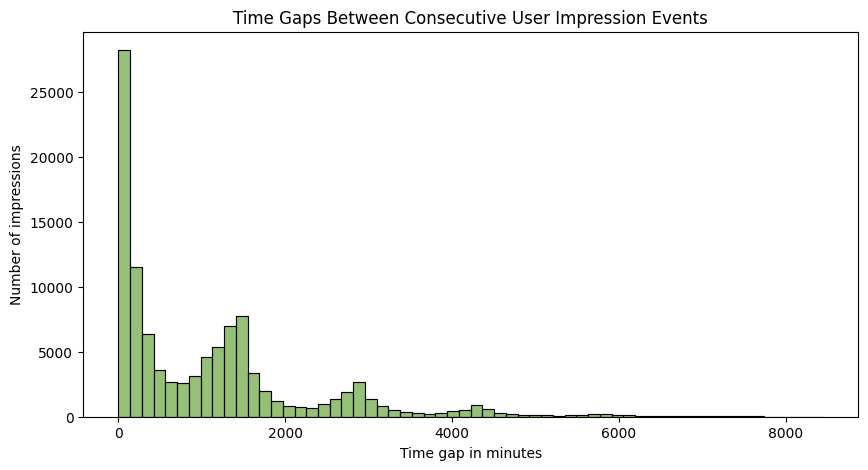

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=time_gaps,
    x="gap_minutes",
    bins=60,
    log_scale=False,
    color="#70AD47"
)

plt.title("Time Gaps Between Consecutive User Impression Events")
plt.xlabel("Time gap in minutes")
plt.ylabel("Number of impressions")
plt.show()

**Observations**:

1. Generally right-skewed, meaning that most impressions happen within 1-2 days of the previous impression